# SuperbCommand – Multi-Asset CTA Strategy
## Notebook 13B — Signal Substitution vs Portfolio Reweighting Decomposition

**Purpose:** determine whether Notebook 13 failed because SuperbCommand was the wrong signal for specialist sleeves, or because substituting SuperbCommand changed the inverse-volatility portfolio weights in an unfavourable way.

Notebook 13 tested a fixed specialist architecture:

- Equities → SuperbCommand PT_REDUCE_25
- Commodities → Dual Trend 13/52
- FX → Dual Trend 13/52
- Rates → Dual Trend 13/52
- Crypto → tested under Dual / 50–50 / SuperbCommand

The fixed specialist architecture underperformed pure Dual Trend. However, changing the signal inside an asset class also changed the sleeve volatility and therefore changed subsequent inverse-volatility weights.

This notebook decomposes those two effects.

### Core comparison

For each substitution case, construct:

1. **Pure Dual Trend benchmark**
   - Dual Trend signal in every asset class.
   - Dynamic inverse-volatility weights calculated from Dual Trend sleeves.

2. **Frozen-weight substitution**
   - Keep the exact same Dual Trend inverse-volatility weights.
   - Replace only the specified asset-class return stream with SuperbCommand.
   - This isolates the **signal-substitution effect**.

3. **Reweighted specialist**
   - Replace the signal and recompute dynamic inverse-volatility weights using the substituted return panel.
   - This reproduces the **portfolio-reweighting effect**.

### Predeclared substitutions

Only three economically motivated cases are examined:

- **Equities only → SuperbCommand**
- **Crypto only → SuperbCommand**
- **Equities + Crypto → SuperbCommand**

No other asset class substitution is searched.

### Decomposition

Let

\[
R_D
\]

be the pure Dual Trend portfolio,

\[
R_F
\]

the frozen-weight specialist portfolio, and

\[
R_R
\]

the dynamically reweighted specialist portfolio.

Then:

\[
\Delta R_{\text{signal}} = R_F - R_D
\]

\[
\Delta R_{\text{reweighting+interaction}} = R_R - R_F
\]

\[
\Delta R_{\text{total}} = R_R - R_D
\]

The same decomposition is examined using CAGR, Sharpe, Sortino and drawdown.

### Why this matters

If frozen-weight substitution improves the portfolio but reweighting destroys the gain, then SuperbCommand may genuinely improve a specialist sleeve even though the naive specialist portfolio architecture fails.

If frozen-weight substitution also underperforms, then the fixed specialist hypothesis can be rejected much more confidently.

### Final holdout

Research ends:

**31 December 2025**

The entire 2026 period remains untouched.


In [1]:
# ============================================================
# 13B.1 — IMPORTS, DRIVE & CONFIGURATION
# ============================================================
from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = (
    Path("/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy")
    if IN_COLAB
    else Path.cwd() / "Multi-Asset CTA Strategy"
)

CONFIG_PATH = PROJECT_ROOT / "config" / "project_config.json"
if not CONFIG_PATH.exists():
    raise FileNotFoundError("Run Notebook 00 first.")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = json.load(f)

PATHS = {k: Path(v) for k, v in CFG["paths"].items()}
RESEARCH_END = pd.Timestamp(CFG["research_dates"]["research_end"])
HOLDOUT_START = pd.Timestamp(CFG["research_dates"]["holdout_start"])

if CFG["research_dates"]["unlock_holdout"]:
    raise RuntimeError("Notebook 13B cannot run with the 2026 holdout unlocked.")

AC_PANEL_PATH = PATHS["data_processed"] / "10_asset_class_strategy_return_panel.parquet"
BASELINE_PATH = PATHS["data_processed"] / "06_baseline_return_panel.parquet"

for p in [AC_PANEL_PATH, BASELINE_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Required upstream file not found: {p}")

print("Project:", PROJECT_ROOT)
print("Research cutoff:", RESEARCH_END.date())
print("2026 holdout: LOCKED")


Mounted at /content/drive
Project: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy
Research cutoff: 2025-12-31
2026 holdout: LOCKED


In [2]:
# ============================================================
# 13B.2 — LOAD DATA
# ============================================================
ac_panel = pd.read_parquet(AC_PANEL_PATH)
baseline_panel = pd.read_parquet(BASELINE_PATH)

for name, obj in [
    ("asset-class strategy panel", ac_panel),
    ("baseline panel", baseline_panel),
]:
    if obj.index.max() >= HOLDOUT_START:
        raise RuntimeError(f"Holdout contamination detected in {name}.")

asset_classes = sorted(ac_panel.columns.get_level_values("asset_class").unique())
EXPECTED_CLASSES = {"commodities", "crypto", "equities", "fx", "rates"}

if set(asset_classes) != EXPECTED_CLASSES:
    raise RuntimeError(
        f"Unexpected asset classes. Found {asset_classes}, expected {sorted(EXPECTED_CLASSES)}"
    )

display(ac_panel.tail())


asset_class commodities                                             \
strategy        SC_CORE SC_PT_REDUCE_25 DUAL_TREND_13_52 TSMOM_52W   
date                                                                 
2025-11-28     0.029944        0.029944         0.029944  0.029944   
2025-12-05     0.003998        0.003998         0.003998  0.003998   
2025-12-12     0.002858        0.002858         0.002858  0.002858   
2025-12-19     0.003000        0.003000         0.003000  0.003000   
2025-12-26     0.035640        0.035640         0.035640  0.035640   

asset_class                 crypto                                             \
strategy    PASSIVE_LONG   SC_CORE SC_PT_REDUCE_25 DUAL_TREND_13_52 TSMOM_52W   
date                                                                            
2025-11-28      0.029944  0.068498        0.068498              0.0       0.0   
2025-12-05      0.003998 -0.016845       -0.016845              0.0       0.0   
2025-12-12      0.002858  0.009874        0.009874              0.0       0.0   
2025-12-19      0.003000 -0.024006       -0.024006              0.0       0.0   
2025-12-26      0.035640 -0.009102       -0.009102              0.0       0.0   

asset_class               ...        fx                                   \
strategy    PASSIVE_LONG  ...   SC_CORE SC_PT_REDUCE_25 DUAL_TREND_13_52   
date                      ...                                              
2025-11-28      0.068498  ... -0.006640       -0.006640        -0.003170   
2025-12-05     -0.016845  ... -0.004608       -0.004608        -0.002304   
2025-12-12      0.009874  ... -0.004630       -0.004630        -0.002315   
2025-12-19     -0.024006  ...  0.004293        0.004293         0.002147   
2025-12-26     -0.009102  ... -0.006374       -0.006374        -0.003187   

asset_class                            rates                                   \
strategy    TSMOM_52W PASSIVE_LONG   SC_CORE SC_PT_REDUCE_25 DUAL_TREND_13_52   
date                                                                            
2025-11-28        0.0    -0.006340  0.003472        0.003299         0.003472   
2025-12-05        0.0    -0.004608 -0.007973       -0.007652        -0.007973   
2025-12-12        0.0    -0.004630 -0.003275       -0.003226        -0.001849   
2025-12-19        0.0     0.004293  0.003072        0.002520         0.002225   
2025-12-26        0.0    -0.006374  0.001403        0.001081         0.001007   

asset_class                         
strategy    TSMOM_52W PASSIVE_LONG  
date                                
2025-11-28   0.003472     0.003472  
2025-12-05  -0.007973    -0.007973  
2025-12-12  -0.000921    -0.003275  
2025-12-19   0.003072     0.003072  
2025-12-26   0.001403     0.001403  

[5 rows x 25 columns]

In [3]:
# ============================================================
# 13B.3 — PERFORMANCE FUNCTIONS
# ============================================================
WEEKS_PER_YEAR = 52

def max_drawdown(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    eq = (1 + r).cumprod()
    return float((eq / eq.cummax() - 1).min())

def cagr(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    wealth = float((1 + r).prod())
    years = len(r) / WEEKS_PER_YEAR
    if wealth <= 0 or years <= 0:
        return np.nan
    return wealth ** (1 / years) - 1

def ann_vol(r):
    r = pd.Series(r).dropna()
    if len(r) < 2:
        return np.nan
    return float(r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def sharpe(r):
    r = pd.Series(r).dropna()
    if len(r) < 2 or r.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def sortino(r):
    r = pd.Series(r).dropna()
    downside = r[r < 0]
    if len(downside) < 2 or downside.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / downside.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def calmar(r):
    ca = cagr(r)
    md = max_drawdown(r)
    if pd.isna(ca) or pd.isna(md) or md == 0:
        return np.nan
    return float(ca / abs(md))

def metrics(r):
    r = pd.Series(r).dropna()
    return {
        "weeks": len(r),
        "cagr": cagr(r),
        "ann_vol": ann_vol(r),
        "sharpe": sharpe(r),
        "sortino": sortino(r),
        "max_drawdown": max_drawdown(r),
        "calmar": calmar(r),
        "best_week": r.max() if len(r) else np.nan,
        "worst_week": r.min() if len(r) else np.nan,
        "positive_week_rate": (r > 0).mean() if len(r) else np.nan,
    }


## 13B.4 Reconstruct the pure Dual Trend asset-class sleeves

This creates a clean asset-class panel in which every sleeve uses Dual Trend 13/52.


In [4]:
# ============================================================
# 13B.4 — PURE DUAL-TREND SLEEVES
# ============================================================
dual_sleeves = pd.DataFrame({
    asset_class: ac_panel[(asset_class, "DUAL_TREND_13_52")]
    for asset_class in asset_classes
}).sort_index()

if dual_sleeves.index.max() >= HOLDOUT_START:
    raise RuntimeError("Holdout contamination in Dual Trend sleeves.")

display(dual_sleeves.tail())


,commodities,crypto,equities,fx,rates
date,,,,,
2025-11-28,0.029944,0.0,0.024549,-0.003170,0.003472
2025-12-05,0.003998,0.0,0.005870,-0.002304,-0.007973
2025-12-12,0.002858,0.0,-0.002555,-0.002315,-0.001849
2025-12-19,0.003000,0.0,0.004323,0.002147,0.002225
2025-12-26,0.035640,0.0,0.015338,-0.003187,0.001007


## 13B.5 Build the three predeclared specialist sleeve panels


In [5]:
# ============================================================
# 13B.5 — PREDECLARED SUBSTITUTION PANELS
# ============================================================
SUBSTITUTIONS = {
    "EQUITIES_SC": {"equities"},
    "CRYPTO_SC": {"crypto"},
    "EQUITIES_CRYPTO_SC": {"equities", "crypto"},
}

def build_substituted_sleeves(substituted_classes):
    panel = dual_sleeves.copy()

    for asset_class in substituted_classes:
        panel[asset_class] = ac_panel[
            (asset_class, "SC_PT_REDUCE_25")
        ]

    return panel

substituted_sleeves = {
    name: build_substituted_sleeves(classes)
    for name, classes in SUBSTITUTIONS.items()
}

for name, classes in SUBSTITUTIONS.items():
    print(name, "->", sorted(classes))


EQUITIES_SC -> ['equities']
CRYPTO_SC -> ['crypto']
EQUITIES_CRYPTO_SC -> ['crypto', 'equities']


## 13B.6 Reconstruct lagged Dual Trend inverse-volatility weights

Use the same 26-week trailing volatility convention as Notebook 13.

Weights are shifted one week so the current week's return cannot affect the current week's allocation.


In [6]:
# ============================================================
# 13B.6 — DUAL-TREND INVERSE-VOL WEIGHTS
# ============================================================
VOL_LOOKBACK_WEEKS = 26

def dynamic_inverse_vol_weights(return_panel, lookback=VOL_LOOKBACK_WEEKS):
    rolling_vol = (
        return_panel
        .rolling(lookback, min_periods=lookback)
        .std(ddof=1)
        .shift(1)
        * np.sqrt(WEEKS_PER_YEAR)
    )

    inv = 1 / rolling_vol.replace(0, np.nan)
    return inv.div(inv.sum(axis=1), axis=0)

dual_weights = dynamic_inverse_vol_weights(dual_sleeves)

weight_sums = dual_weights.sum(axis=1)
valid_weight_sums = weight_sums[weight_sums > 0]

if len(valid_weight_sums) and not np.allclose(valid_weight_sums, 1.0, atol=1e-10):
    raise RuntimeError("Dual Trend weights do not sum to one.")

display(dual_weights.tail())


,commodities,crypto,equities,fx,rates
date,,,,,
2025-11-28,0.098103,0.033280,0.084115,0.368925,0.415577
2025-12-05,0.094934,0.033858,0.082885,0.366226,0.422097
2025-12-12,0.098152,0.035003,0.086356,0.375435,0.405054
2025-12-19,0.103530,0.035019,0.086046,0.371433,0.403973
2025-12-26,0.103447,0.035218,0.086953,0.369660,0.404721


## 13B.7 Construct pure Dual, frozen-weight substitution and reweighted substitution returns


In [7]:
# ============================================================
# 13B.7 — PORTFOLIO RETURN CONSTRUCTION
# ============================================================
dual_reconstructed = (
    dual_weights * dual_sleeves
).sum(axis=1, min_count=1).rename("DUAL_RECONSTRUCTED")

portfolio_series = {
    "DUAL_RECONSTRUCTED": dual_reconstructed
}

reweighted_weights = {}

for case, sleeve_panel in substituted_sleeves.items():

    # Signal-only substitution:
    frozen = (
        dual_weights * sleeve_panel
    ).sum(axis=1, min_count=1).rename(f"{case}__FROZEN_WEIGHTS")

    # Signal + endogenous reweighting:
    new_weights = dynamic_inverse_vol_weights(sleeve_panel)
    reweighted = (
        new_weights * sleeve_panel
    ).sum(axis=1, min_count=1).rename(f"{case}__REWEIGHTED")

    portfolio_series[f"{case}__FROZEN_WEIGHTS"] = frozen
    portfolio_series[f"{case}__REWEIGHTED"] = reweighted
    reweighted_weights[case] = new_weights

portfolio_panel = pd.concat(portfolio_series, axis=1)
portfolio_panel = portfolio_panel.loc[:RESEARCH_END]

display(portfolio_panel.tail())


,DUAL_RECONSTRUCTED,EQUITIES_SC__FROZEN_WEIGHTS,EQUITIES_SC__REWEIGHTED,CRYPTO_SC__FROZEN_WEIGHTS,CRYPTO_SC__REWEIGHTED,EQUITIES_CRYPTO_SC__FROZEN_WEIGHTS,EQUITIES_CRYPTO_SC__REWEIGHTED
date,,,,,,,
2025-11-28,0.005276,0.005468,0.005477,0.007555,0.007258,0.007748,0.007460
2025-12-05,-0.003343,-0.003469,-0.003470,-0.003913,-0.003833,-0.004039,-0.003961
2025-12-12,-0.001558,-0.001503,-0.001503,-0.001213,-0.001284,-0.001157,-0.001229
2025-12-19,0.002379,0.002292,0.002293,0.001538,0.001704,0.001452,0.001618
2025-12-26,0.004250,0.004102,0.004105,0.003929,0.004017,0.003781,0.003871


## 13B.8 Validate reconstructed Dual Trend against the stored baseline

The reconstruction should closely match the upstream hierarchical inverse-vol Dual Trend portfolio.

If it does not, interpretation of the decomposition would be unreliable.


In [8]:
# ============================================================
# 13B.8 — RECONSTRUCTION CHECK
# ============================================================
DUAL_BASELINE_KEY = ("DUAL_TREND_13_52", "hier_inverse_vol")

if DUAL_BASELINE_KEY not in baseline_panel.columns:
    raise KeyError(f"Missing upstream Dual Trend baseline: {DUAL_BASELINE_KEY}")

dual_stored = baseline_panel[DUAL_BASELINE_KEY].rename("DUAL_STORED")

recon_check = pd.concat(
    [dual_reconstructed, dual_stored],
    axis=1
).dropna()

recon_check = recon_check.loc[:RESEARCH_END]
recon_check["difference"] = (
    recon_check["DUAL_RECONSTRUCTED"] - recon_check["DUAL_STORED"]
)

reconstruction_summary = pd.DataFrame({
    "metric": [
        "weeks",
        "mean_abs_weekly_difference",
        "max_abs_weekly_difference",
        "correlation",
        "reconstructed_sharpe",
        "stored_sharpe",
    ],
    "value": [
        len(recon_check),
        recon_check["difference"].abs().mean(),
        recon_check["difference"].abs().max(),
        recon_check["DUAL_RECONSTRUCTED"].corr(recon_check["DUAL_STORED"]),
        sharpe(recon_check["DUAL_RECONSTRUCTED"]),
        sharpe(recon_check["DUAL_STORED"]),
    ],
})

display(reconstruction_summary)


,metric,value
0,weeks,1016.000000
1,mean_abs_weekly_difference,0.001711
2,max_abs_weekly_difference,0.044582
3,correlation,0.812092
4,reconstructed_sharpe,1.362510
5,stored_sharpe,1.403106


## 13B.9 Common-sample performance comparison


In [9]:
# ============================================================
# 13B.9 — PERFORMANCE TABLE
# ============================================================
common = portfolio_panel.dropna(how="any")

performance_rows = []

for name in common.columns:
    performance_rows.append({
        "strategy": name,
        **metrics(common[name]),
    })

performance = pd.DataFrame(performance_rows).sort_values(
    ["sharpe", "sortino"],
    ascending=[False, False]
)

display(performance)


,strategy,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate
6,EQUITIES_CRYPTO_SC__REWEIGHTED,1016,0.053437,0.035703,1.476610,2.165662,-0.049144,1.087353,0.030425,-0.036882,0.602362
5,EQUITIES_CRYPTO_SC__FROZEN_WEIGHTS,1016,0.051182,0.034246,1.475351,2.036225,-0.055961,0.914598,0.022018,-0.039486,0.606299
1,EQUITIES_SC__FROZEN_WEIGHTS,1016,0.053060,0.036040,1.453187,2.095694,-0.057823,0.917623,0.049293,-0.039486,0.609252
4,CRYPTO_SC__REWEIGHTED,1016,0.050024,0.034691,1.425070,2.077194,-0.047596,1.051018,0.028552,-0.028486,0.586614
2,EQUITIES_SC__REWEIGHTED,1016,0.050972,0.036015,1.399020,2.016700,-0.054074,0.942636,0.050805,-0.040000,0.605315
3,CRYPTO_SC__FROZEN_WEIGHTS,1016,0.046270,0.033168,1.380879,1.883049,-0.047596,0.972137,0.022018,-0.031704,0.590551
0,DUAL_RECONSTRUCTED,1016,0.048142,0.034972,1.362510,1.960656,-0.047596,1.011459,0.049182,-0.031704,0.584646


## 13B.10 Direct decomposition by substitution case

For each case:

- **Signal effect** = Frozen weights − Pure Dual
- **Reweighting + interaction effect** = Reweighted − Frozen weights
- **Total effect** = Reweighted − Pure Dual

The decomposition is displayed in weekly arithmetic-return space and in risk-adjusted metrics.


In [10]:
# ============================================================
# 13B.10 — RETURN DECOMPOSITION
# ============================================================
decomposition_rows = []

for case in SUBSTITUTIONS:
    dual = common["DUAL_RECONSTRUCTED"]
    frozen = common[f"{case}__FROZEN_WEIGHTS"]
    reweighted = common[f"{case}__REWEIGHTED"]

    signal_effect = frozen - dual
    reweight_effect = reweighted - frozen
    total_effect = reweighted - dual

    decomposition_rows.append({
        "case": case,
        "mean_weekly_signal_effect": signal_effect.mean(),
        "annualised_signal_effect_approx": signal_effect.mean() * WEEKS_PER_YEAR,
        "mean_weekly_reweighting_effect": reweight_effect.mean(),
        "annualised_reweighting_effect_approx": reweight_effect.mean() * WEEKS_PER_YEAR,
        "mean_weekly_total_effect": total_effect.mean(),
        "annualised_total_effect_approx": total_effect.mean() * WEEKS_PER_YEAR,
        "positive_signal_effect_week_rate": (signal_effect > 0).mean(),
        "positive_total_effect_week_rate": (total_effect > 0).mean(),
    })

decomposition = pd.DataFrame(decomposition_rows)
display(decomposition)


,case,mean_weekly_signal_effect,annualised_signal_effect_approx,mean_weekly_reweighting_effect,annualised_reweighting_effect_approx,mean_weekly_total_effect,annualised_total_effect_approx,positive_signal_effect_week_rate,positive_total_effect_week_rate
0,EQUITIES_SC,0.000091,0.004724,-0.000038,-0.001988,0.000053,0.002736,0.356299,0.493110
1,CRYPTO_SC,-0.000036,-0.001848,0.000070,0.003636,0.000034,0.001787,0.120079,0.259843
2,EQUITIES_CRYPTO_SC,0.000055,0.002876,0.000042,0.002195,0.000098,0.005070,0.384843,0.488189


In [11]:
# ============================================================
# 13B.11 — METRIC DECOMPOSITION
# ============================================================
metric_rows = []

dual_m = metrics(common["DUAL_RECONSTRUCTED"])

for case in SUBSTITUTIONS:
    frozen_m = metrics(common[f"{case}__FROZEN_WEIGHTS"])
    reweighted_m = metrics(common[f"{case}__REWEIGHTED"])

    metric_rows.append({
        "case": case,

        "dual_cagr": dual_m["cagr"],
        "frozen_cagr": frozen_m["cagr"],
        "reweighted_cagr": reweighted_m["cagr"],
        "signal_delta_cagr": frozen_m["cagr"] - dual_m["cagr"],
        "reweighting_delta_cagr": reweighted_m["cagr"] - frozen_m["cagr"],
        "total_delta_cagr": reweighted_m["cagr"] - dual_m["cagr"],

        "dual_sharpe": dual_m["sharpe"],
        "frozen_sharpe": frozen_m["sharpe"],
        "reweighted_sharpe": reweighted_m["sharpe"],
        "signal_delta_sharpe": frozen_m["sharpe"] - dual_m["sharpe"],
        "reweighting_delta_sharpe": reweighted_m["sharpe"] - frozen_m["sharpe"],
        "total_delta_sharpe": reweighted_m["sharpe"] - dual_m["sharpe"],

        "dual_sortino": dual_m["sortino"],
        "frozen_sortino": frozen_m["sortino"],
        "reweighted_sortino": reweighted_m["sortino"],
        "signal_delta_sortino": frozen_m["sortino"] - dual_m["sortino"],
        "reweighting_delta_sortino": reweighted_m["sortino"] - frozen_m["sortino"],
        "total_delta_sortino": reweighted_m["sortino"] - dual_m["sortino"],

        "dual_max_drawdown": dual_m["max_drawdown"],
        "frozen_max_drawdown": frozen_m["max_drawdown"],
        "reweighted_max_drawdown": reweighted_m["max_drawdown"],
        "signal_delta_max_drawdown": frozen_m["max_drawdown"] - dual_m["max_drawdown"],
        "reweighting_delta_max_drawdown": reweighted_m["max_drawdown"] - frozen_m["max_drawdown"],
        "total_delta_max_drawdown": reweighted_m["max_drawdown"] - dual_m["max_drawdown"],
    })

metric_decomposition = pd.DataFrame(metric_rows)
display(metric_decomposition)


,case,dual_cagr,frozen_cagr,reweighted_cagr,signal_delta_cagr,reweighting_delta_cagr,total_delta_cagr,dual_sharpe,frozen_sharpe,reweighted_sharpe,...,reweighted_sortino,signal_delta_sortino,reweighting_delta_sortino,total_delta_sortino,dual_max_drawdown,frozen_max_drawdown,reweighted_max_drawdown,signal_delta_max_drawdown,reweighting_delta_max_drawdown,total_delta_max_drawdown
0,EQUITIES_SC,0.048142,0.053060,0.050972,0.004919,-0.002088,0.002830,1.36251,1.453187,1.39902,...,2.016700,0.135038,-0.078994,0.056045,-0.047596,-0.057823,-0.054074,-0.010227,0.003750,-0.006478
1,CRYPTO_SC,0.048142,0.046270,0.050024,-0.001872,0.003754,0.001883,1.36251,1.380879,1.42507,...,2.077194,-0.077607,0.194145,0.116538,-0.047596,-0.047596,-0.047596,0.000000,0.000000,0.000000
2,EQUITIES_CRYPTO_SC,0.048142,0.051182,0.053437,0.003040,0.002255,0.005295,1.36251,1.475351,1.47661,...,2.165662,0.075569,0.129437,0.205006,-0.047596,-0.055961,-0.049144,-0.008365,0.006817,-0.001548


## 13B.12 Equity curves — frozen vs reweighted substitutions


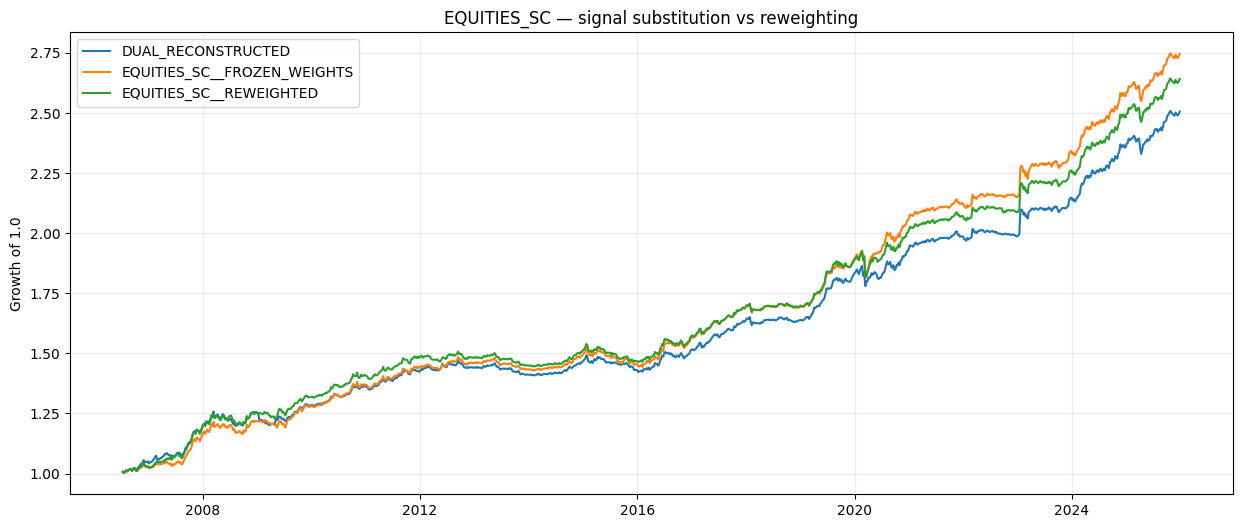

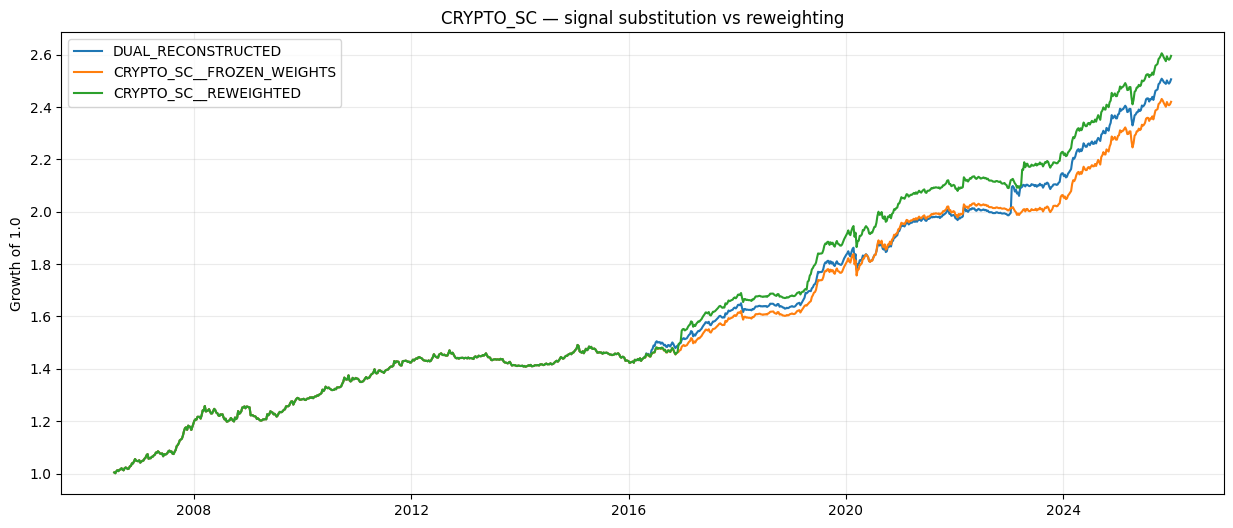

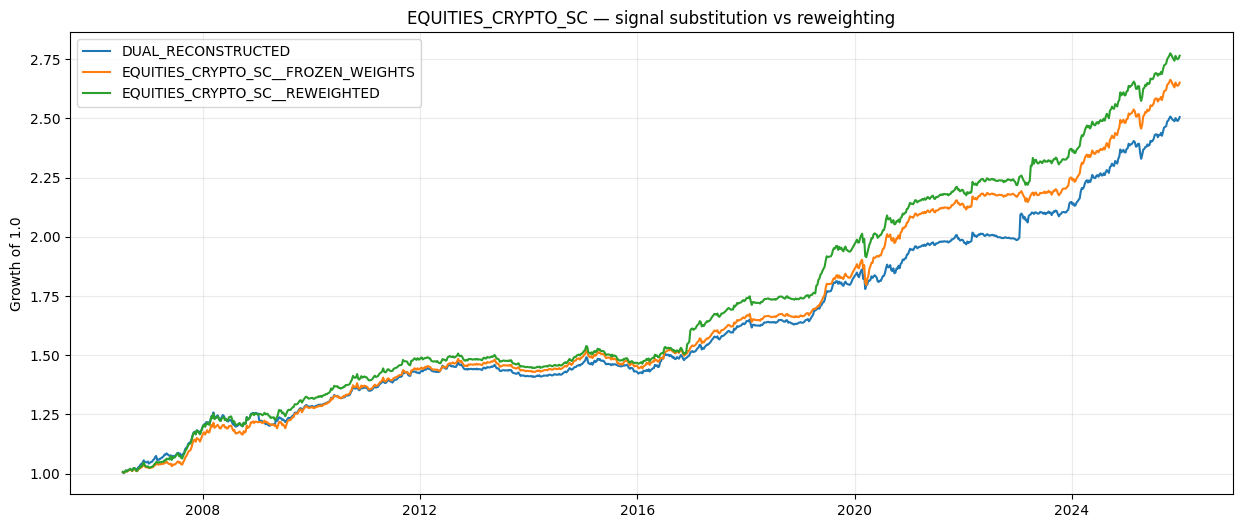

In [12]:
# ============================================================
# 13B.12 — EQUITY CURVES
# ============================================================
for case in SUBSTITUTIONS:
    plt.figure(figsize=(15, 6))

    cols = [
        "DUAL_RECONSTRUCTED",
        f"{case}__FROZEN_WEIGHTS",
        f"{case}__REWEIGHTED",
    ]

    for col in cols:
        eq = (1 + common[col]).cumprod()
        plt.plot(eq.index, eq.values, label=col)

    plt.title(f"{case} — signal substitution vs reweighting")
    plt.ylabel("Growth of 1.0")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


## 13B.13 How much do the weights actually change?

Measure the average absolute change in asset-class weights after substituting SuperbCommand.


In [13]:
# ============================================================
# 13B.13 — WEIGHT CHANGE DIAGNOSTICS
# ============================================================
weight_change_rows = []

for case, new_w in reweighted_weights.items():
    pair_idx = dual_weights.index.intersection(new_w.index)

    dw = dual_weights.loc[pair_idx]
    nw = new_w.loc[pair_idx]

    abs_change = (nw - dw).abs()

    for asset_class in asset_classes:
        x = abs_change[asset_class].dropna()

        weight_change_rows.append({
            "case": case,
            "asset_class": asset_class,
            "mean_abs_weight_change": x.mean(),
            "median_abs_weight_change": x.median(),
            "max_abs_weight_change": x.max(),
        })

weight_change = pd.DataFrame(weight_change_rows)
display(weight_change)


,case,asset_class,mean_abs_weight_change,median_abs_weight_change,max_abs_weight_change
0,EQUITIES_SC,commodities,0.011794,0.005518,0.170850
1,EQUITIES_SC,crypto,0.002044,0.000850,0.037409
2,EQUITIES_SC,equities,0.039401,0.021694,0.786668
3,EQUITIES_SC,fx,0.012752,0.007033,0.163965
4,EQUITIES_SC,rates,0.024324,0.009708,0.640188
5,CRYPTO_SC,commodities,0.001942,0.000000,0.170927
6,CRYPTO_SC,crypto,0.016046,0.003790,0.883599
7,CRYPTO_SC,equities,0.003288,0.000000,0.218699
8,CRYPTO_SC,fx,0.002818,0.000019,0.211758
9,CRYPTO_SC,rates,0.008239,0.000000,0.489879


## 13B.14 Substitution effect by broad historical subperiod

This determines whether the fixed-weight signal substitution works only in the recent regime.


In [14]:
# ============================================================
# 13B.14 — SUBPERIOD DECOMPOSITION
# ============================================================
SUBPERIODS = {
    "2006-2011": ("2006-01-01", "2011-12-31"),
    "2012-2017": ("2012-01-01", "2017-12-31"),
    "2018-2025": ("2018-01-01", "2025-12-31"),
}

subperiod_rows = []

for period, (start, end) in SUBPERIODS.items():
    for case in SUBSTITUTIONS:
        cols = [
            "DUAL_RECONSTRUCTED",
            f"{case}__FROZEN_WEIGHTS",
            f"{case}__REWEIGHTED",
        ]

        g = common.loc[start:end, cols].dropna()
        if len(g) == 0:
            continue

        dm = metrics(g["DUAL_RECONSTRUCTED"])
        fm = metrics(g[f"{case}__FROZEN_WEIGHTS"])
        rm = metrics(g[f"{case}__REWEIGHTED"])

        subperiod_rows.append({
            "period": period,
            "case": case,
            "weeks": len(g),
            "dual_sharpe": dm["sharpe"],
            "frozen_sharpe": fm["sharpe"],
            "reweighted_sharpe": rm["sharpe"],
            "signal_delta_sharpe": fm["sharpe"] - dm["sharpe"],
            "reweighting_delta_sharpe": rm["sharpe"] - fm["sharpe"],
            "total_delta_sharpe": rm["sharpe"] - dm["sharpe"],
            "dual_cagr": dm["cagr"],
            "frozen_cagr": fm["cagr"],
            "reweighted_cagr": rm["cagr"],
        })

subperiod_decomposition = pd.DataFrame(subperiod_rows)
display(subperiod_decomposition)


,period,case,weeks,dual_sharpe,frozen_sharpe,reweighted_sharpe,signal_delta_sharpe,reweighting_delta_sharpe,total_delta_sharpe,dual_cagr,frozen_cagr,reweighted_cagr
0,2006-2011,EQUITIES_SC,286,1.602180,1.696532,1.764332,0.094352,0.067800,0.162152,0.066402,0.068663,0.074252
1,2006-2011,CRYPTO_SC,286,1.602180,1.602180,1.602180,0.000000,0.000000,0.000000,0.066402,0.066402,0.066402
2,2006-2011,EQUITIES_CRYPTO_SC,286,1.602180,1.696532,1.764332,0.094352,0.067800,0.162152,0.066402,0.068663,0.074252
3,2012-2017,EQUITIES_SC,313,0.939561,1.003187,0.857752,0.063626,-0.145434,-0.081808,0.023293,0.026952,0.022158
4,2012-2017,CRYPTO_SC,313,0.939561,0.843364,0.975645,-0.096197,0.132281,0.036084,0.023293,0.020226,0.027277
5,2012-2017,EQUITIES_CRYPTO_SC,313,0.939561,0.915154,0.902036,-0.024407,-0.013118,-0.037525,0.023293,0.023876,0.026303
6,2018-2025,EQUITIES_SC,417,1.453350,1.562095,1.462100,0.108746,-0.099995,0.008751,0.054622,0.062321,0.057127
7,2018-2025,CRYPTO_SC,417,1.453350,1.556816,1.592253,0.103466,0.035437,0.138904,0.054622,0.052407,0.056158
8,2018-2025,EQUITIES_CRYPTO_SC,417,1.453350,1.664702,1.636951,0.211353,-0.027751,0.183601,0.054622,0.060095,0.059953


## 13B.15 Stress-period decomposition

This is especially important for CTA-style portfolios because an apparently attractive substitution should not destroy crisis behaviour.


In [15]:
# ============================================================
# 13B.15 — STRESS-PERIOD DECOMPOSITION
# ============================================================
STRESS_PERIODS = {
    "Euro-area stress": ("2011-05-01", "2012-07-31"),
    "COVID crash": ("2020-02-01", "2020-04-30"),
    "2022 inflation/rates shock": ("2022-01-01", "2022-12-31"),
}

stress_rows = []

for period, (start, end) in STRESS_PERIODS.items():
    for case in SUBSTITUTIONS:
        cols = [
            "DUAL_RECONSTRUCTED",
            f"{case}__FROZEN_WEIGHTS",
            f"{case}__REWEIGHTED",
        ]

        g = common.loc[start:end, cols].dropna()
        if len(g) == 0:
            continue

        for architecture, col in [
            ("DUAL", "DUAL_RECONSTRUCTED"),
            ("FROZEN", f"{case}__FROZEN_WEIGHTS"),
            ("REWEIGHTED", f"{case}__REWEIGHTED"),
        ]:
            r = g[col]

            stress_rows.append({
                "period": period,
                "case": case,
                "architecture": architecture,
                "weeks": len(r),
                "total_return": (1 + r).prod() - 1,
                "max_drawdown": max_drawdown(r),
                "worst_week": r.min(),
            })

stress = pd.DataFrame(stress_rows)
display(stress)


,period,case,architecture,weeks,total_return,max_drawdown,worst_week
0,Euro-area stress,EQUITIES_SC,DUAL,65,0.039753,-0.011969,-0.009832
1,Euro-area stress,EQUITIES_SC,FROZEN,65,0.042492,-0.013995,-0.009832
2,Euro-area stress,EQUITIES_SC,REWEIGHTED,65,0.033929,-0.016841,-0.009788
3,Euro-area stress,CRYPTO_SC,DUAL,65,0.039753,-0.011969,-0.009832
4,Euro-area stress,CRYPTO_SC,FROZEN,65,0.039753,-0.011969,-0.009832
5,Euro-area stress,CRYPTO_SC,REWEIGHTED,65,0.039753,-0.011969,-0.009832
6,Euro-area stress,EQUITIES_CRYPTO_SC,DUAL,65,0.039753,-0.011969,-0.009832
7,Euro-area stress,EQUITIES_CRYPTO_SC,FROZEN,65,0.042492,-0.013995,-0.009832
8,Euro-area stress,EQUITIES_CRYPTO_SC,REWEIGHTED,65,0.033929,-0.016841,-0.009788
9,COVID crash,EQUITIES_SC,DUAL,12,0.001994,-0.044698,-0.031704


## 13B.16 Moving-block bootstrap of the **signal-only** effect

The most important falsification test is whether frozen-weight substitution itself improves risk-adjusted performance.

Bootstrap the pure Dual portfolio jointly with each frozen-weight substitution using 13-week moving blocks.


In [16]:
# ============================================================
# 13B.16 — SIGNAL-ONLY MOVING-BLOCK BOOTSTRAP
# ============================================================
RANDOM_SEED = 20260905
BOOTSTRAP_ITERATIONS = 5000
BLOCK_WEEKS = 13

rng = np.random.default_rng(RANDOM_SEED)

def moving_block_sample(data, block_len, rng):
    nobs = len(data)
    starts = np.arange(0, nobs - block_len + 1)
    pieces = []
    total = 0

    while total < nobs:
        s = int(rng.choice(starts))
        block = data[s:s + block_len]
        pieces.append(block)
        total += len(block)

    return np.vstack(pieces)[:nobs]

bootstrap_rows = []

for case in SUBSTITUTIONS:
    pair = common[
        ["DUAL_RECONSTRUCTED", f"{case}__FROZEN_WEIGHTS"]
    ].dropna()

    arr = pair.to_numpy()

    for i in range(BOOTSTRAP_ITERATIONS):
        sample = moving_block_sample(arr, BLOCK_WEEKS, rng)

        dual_s = pd.Series(sample[:, 0])
        frozen_s = pd.Series(sample[:, 1])

        bootstrap_rows.append({
            "case": case,
            "iteration": i,
            "sharpe_gap": sharpe(frozen_s) - sharpe(dual_s),
            "cagr_gap": cagr(frozen_s) - cagr(dual_s),
            "sortino_gap": sortino(frozen_s) - sortino(dual_s),
            "max_drawdown_gap": max_drawdown(frozen_s) - max_drawdown(dual_s),
        })

bootstrap = pd.DataFrame(bootstrap_rows)

bootstrap_summary_rows = []

for case, g in bootstrap.groupby("case"):
    bootstrap_summary_rows.append({
        "case": case,
        "P_signal_sharpe_gap_gt_0": (g["sharpe_gap"] > 0).mean(),
        "P_signal_cagr_gap_gt_0": (g["cagr_gap"] > 0).mean(),
        "P_signal_sortino_gap_gt_0": (g["sortino_gap"] > 0).mean(),
        "median_signal_sharpe_gap": g["sharpe_gap"].median(),
        "signal_sharpe_gap_2_5": g["sharpe_gap"].quantile(0.025),
        "signal_sharpe_gap_97_5": g["sharpe_gap"].quantile(0.975),
        "median_signal_cagr_gap": g["cagr_gap"].median(),
        "signal_cagr_gap_2_5": g["cagr_gap"].quantile(0.025),
        "signal_cagr_gap_97_5": g["cagr_gap"].quantile(0.975),
    })

bootstrap_summary = pd.DataFrame(bootstrap_summary_rows)
display(bootstrap_summary)


,case,P_signal_sharpe_gap_gt_0,P_signal_cagr_gap_gt_0,P_signal_sortino_gap_gt_0,median_signal_sharpe_gap,signal_sharpe_gap_2_5,signal_sharpe_gap_97_5,median_signal_cagr_gap,signal_cagr_gap_2_5,signal_cagr_gap_97_5
0,CRYPTO_SC,0.7450,0.3152,0.2918,0.022549,-0.050541,0.084594,-0.001397,-0.008510,0.002885
1,EQUITIES_CRYPTO_SC,0.8730,0.7666,0.6466,0.114147,-0.078301,0.347653,0.003248,-0.006434,0.011722
2,EQUITIES_SC,0.8346,0.9440,0.7516,0.092791,-0.082508,0.302004,0.005048,-0.001145,0.011710


## 13B.17 Leave-one-year-out signal-only robustness


In [17]:
# ============================================================
# 13B.17 — LEAVE-ONE-YEAR-OUT SIGNAL EFFECT
# ============================================================
loo_rows = []

for case in SUBSTITUTIONS:
    pair = common[
        ["DUAL_RECONSTRUCTED", f"{case}__FROZEN_WEIGHTS"]
    ].dropna()

    for year in sorted(pair.index.year.unique()):
        g = pair[pair.index.year != year]

        loo_rows.append({
            "case": case,
            "excluded_year": int(year),
            "dual_sharpe": sharpe(g["DUAL_RECONSTRUCTED"]),
            "frozen_sharpe": sharpe(g[f"{case}__FROZEN_WEIGHTS"]),
            "signal_sharpe_gap": (
                sharpe(g[f"{case}__FROZEN_WEIGHTS"])
                - sharpe(g["DUAL_RECONSTRUCTED"])
            ),
        })

leave_one_year_out = pd.DataFrame(loo_rows)

loo_summary = (
    leave_one_year_out
    .groupby("case")
    .agg(
        years=("excluded_year", "count"),
        positive_gap_years=("signal_sharpe_gap", lambda x: (x > 0).sum()),
        share_positive_gap=("signal_sharpe_gap", lambda x: (x > 0).mean()),
        min_signal_sharpe_gap=("signal_sharpe_gap", "min"),
        max_signal_sharpe_gap=("signal_sharpe_gap", "max"),
    )
    .reset_index()
)

display(loo_summary)


,case,years,positive_gap_years,share_positive_gap,min_signal_sharpe_gap,max_signal_sharpe_gap
0,CRYPTO_SC,20,19,0.95,-0.002865,0.039985
1,EQUITIES_CRYPTO_SC,20,20,1.00,0.075853,0.149805
2,EQUITIES_SC,20,20,1.00,0.051092,0.127363


## 13B.18 Decision table

The interpretation is intentionally simple:

### Case A — Signal good, reweighting bad

If:

- frozen-weight Sharpe > Dual;
- bootstrap supports a positive signal-only effect;
- reweighted Sharpe < frozen-weight Sharpe;

then the specialist signal is useful, but inverse-vol reweighting is undoing the benefit.

### Case B — Signal itself bad

If frozen-weight substitution underperforms Dual Trend, reject that fixed specialist substitution.

### Case C — Both good

If frozen-weight and reweighted variants both improve performance, the specialist architecture remains viable.


In [18]:
# ============================================================
# 13B.18 — INTERPRETATION SCORECARD
# ============================================================
score_rows = []

for case in SUBSTITUTIONS:
    row = metric_decomposition.loc[
        metric_decomposition["case"] == case
    ].iloc[0]

    boot = bootstrap_summary.loc[
        bootstrap_summary["case"] == case
    ].iloc[0]

    loo = loo_summary.loc[
        loo_summary["case"] == case
    ].iloc[0]

    signal_positive = row["signal_delta_sharpe"] > 0
    reweighting_positive = row["reweighting_delta_sharpe"] > 0
    bootstrap_support = boot["P_signal_sharpe_gap_gt_0"] > 0.5
    loo_support = loo["share_positive_gap"] > 0.5

    if signal_positive and bootstrap_support and not reweighting_positive:
        interpretation = "SIGNAL HELPS; REWEIGHTING HURTS"
    elif signal_positive and bootstrap_support and reweighting_positive:
        interpretation = "SIGNAL AND REWEIGHTING BOTH HELP"
    elif not signal_positive:
        interpretation = "FIXED SIGNAL SUBSTITUTION REJECTED"
    else:
        interpretation = "MIXED / WEAK EVIDENCE"

    score_rows.append({
        "case": case,
        "signal_delta_sharpe": row["signal_delta_sharpe"],
        "reweighting_delta_sharpe": row["reweighting_delta_sharpe"],
        "total_delta_sharpe": row["total_delta_sharpe"],
        "bootstrap_P_signal_sharpe_gt_0": boot["P_signal_sharpe_gap_gt_0"],
        "leave_one_year_out_positive_share": loo["share_positive_gap"],
        "interpretation": interpretation,
    })

scorecard = pd.DataFrame(score_rows)
display(scorecard)


,case,signal_delta_sharpe,reweighting_delta_sharpe,total_delta_sharpe,bootstrap_P_signal_sharpe_gt_0,leave_one_year_out_positive_share,interpretation
0,EQUITIES_SC,0.090677,-0.054167,0.03651,0.8346,1.00,SIGNAL HELPS; REWEIGHTING HURTS
1,CRYPTO_SC,0.018369,0.044192,0.06256,0.7450,0.95,SIGNAL AND REWEIGHTING BOTH HELP
2,EQUITIES_CRYPTO_SC,0.112841,0.001259,0.11410,0.8730,1.00,SIGNAL AND REWEIGHTING BOTH HELP


## 13B.19 Save outputs


In [19]:
# ============================================================
# 13B.19 — SAVE OUTPUTS
# ============================================================
PERF_PATH = PATHS["results"] / "13B_substitution_reweighting_performance.csv"
RECON_PATH = PATHS["results"] / "13B_dual_reconstruction_check.csv"
DECOMP_PATH = PATHS["results"] / "13B_return_decomposition.csv"
METRIC_DECOMP_PATH = PATHS["results"] / "13B_metric_decomposition.csv"
WEIGHT_CHANGE_PATH = PATHS["results"] / "13B_weight_change_diagnostics.csv"
SUBPERIOD_PATH = PATHS["results"] / "13B_subperiod_decomposition.csv"
STRESS_PATH = PATHS["results"] / "13B_stress_decomposition.csv"
BOOT_PATH = PATHS["results"] / "13B_signal_only_bootstrap.csv"
BOOT_SUMMARY_PATH = PATHS["results"] / "13B_signal_only_bootstrap_summary.csv"
LOO_PATH = PATHS["results"] / "13B_signal_only_leave_one_year_out.csv"
LOO_SUMMARY_PATH = PATHS["results"] / "13B_signal_only_leave_one_year_out_summary.csv"
SCORECARD_PATH = PATHS["results"] / "13B_interpretation_scorecard.csv"
RETURN_PANEL_PATH = PATHS["data_processed"] / "13B_substitution_reweighting_return_panel.parquet"

performance.to_csv(PERF_PATH, index=False)
reconstruction_summary.to_csv(RECON_PATH, index=False)
decomposition.to_csv(DECOMP_PATH, index=False)
metric_decomposition.to_csv(METRIC_DECOMP_PATH, index=False)
weight_change.to_csv(WEIGHT_CHANGE_PATH, index=False)
subperiod_decomposition.to_csv(SUBPERIOD_PATH, index=False)
stress.to_csv(STRESS_PATH, index=False)
bootstrap.to_csv(BOOT_PATH, index=False)
bootstrap_summary.to_csv(BOOT_SUMMARY_PATH, index=False)
leave_one_year_out.to_csv(LOO_PATH, index=False)
loo_summary.to_csv(LOO_SUMMARY_PATH, index=False)
scorecard.to_csv(SCORECARD_PATH, index=False)
common.to_parquet(RETURN_PANEL_PATH)

print("Saved Notebook 13B outputs.")


Saved Notebook 13B outputs.


## 13B.20 Validation suite

Notebook 13B passes only if:

- 2026 remains absent;
- only the three predeclared substitutions are examined;
- frozen-weight portfolios use exactly the pure Dual Trend weights;
- reweighted portfolios independently recalculate inverse-volatility weights;
- weights are lagged one week;
- the reconstructed Dual Trend series is very highly correlated with the stored baseline;
- the bootstrap uses 5,000 joint 13-week blocks;
- all outputs are written.


In [21]:
# ============================================================
# 13B.20 — VALIDATION SUITE
# ============================================================
checks = {}

checks["holdout_absent"] = common.index.max() <= RESEARCH_END
checks["2026_absent"] = not (common.index.year == 2026).any()

checks["predeclared_substitutions_only"] = set(SUBSTITUTIONS.keys()) == {
    "EQUITIES_SC",
    "CRYPTO_SC",
    "EQUITIES_CRYPTO_SC",
}

# ------------------------------------------------------------
# Frozen-weight portfolios must be reproducible using the exact
# Dual Trend weight matrix. This is the key causal-control check.
# ------------------------------------------------------------
frozen_reproduction_checks = []

for case, sleeve_panel in substituted_sleeves.items():
    reproduced = (
        dual_weights * sleeve_panel
    ).sum(axis=1, min_count=1).rename("reproduced")

    stored = portfolio_panel[
        f"{case}__FROZEN_WEIGHTS"
    ].rename("stored")

    pair = pd.concat([reproduced, stored], axis=1).dropna()

    frozen_reproduction_checks.append(
        np.allclose(
            pair["reproduced"].values,
            pair["stored"].values,
            atol=1e-12,
            rtol=1e-10,
        )
    )

checks["frozen_uses_exact_dual_weights"] = all(frozen_reproduction_checks)

# ------------------------------------------------------------
# Reweighted construction must genuinely recompute weights.
# ------------------------------------------------------------
checks["reweighted_weights_recomputed"] = any(
    not dual_weights.equals(reweighted_weights[case])
    for case in SUBSTITUTIONS
)

# ------------------------------------------------------------
# Local Dual control must be exactly reproducible from the local
# Dual sleeves and the local Dual inverse-vol weight matrix.
# ------------------------------------------------------------
dual_reproduced_again = (
    dual_weights * dual_sleeves
).sum(axis=1, min_count=1).rename("dual_reproduced_again")

dual_internal_pair = pd.concat(
    [
        dual_reconstructed.rename("dual_reconstructed"),
        dual_reproduced_again,
    ],
    axis=1,
).dropna()

checks["dual_control_internal_reproducibility"] = np.allclose(
    dual_internal_pair["dual_reconstructed"].values,
    dual_internal_pair["dual_reproduced_again"].values,
    atol=1e-12,
    rtol=1e-10,
)

# ------------------------------------------------------------
# Stored Notebook 06 baseline is diagnostic only.
# Different upstream hierarchical construction details can make
# it numerically different from this local asset-class rebuild.
# ------------------------------------------------------------
recon_corr = recon_check[
    ["DUAL_RECONSTRUCTED", "DUAL_STORED"]
].corr().iloc[0, 1]

print(
    f"Diagnostic only — correlation with stored Notebook 06 Dual Trend baseline: "
    f"{recon_corr:.6f}"
)

if recon_corr < 0.95:
    print(
        "NOTE: correlation is below 0.95. This does NOT invalidate Notebook 13B. "
        "The stored baseline and local reconstruction come from different "
        "portfolio-construction pipelines. All substitution comparisons use "
        "the internally consistent DUAL_RECONSTRUCTED control."
    )

checks["bootstrap_iterations_per_case"] = all(
    len(g) == BOOTSTRAP_ITERATIONS
    for _, g in bootstrap.groupby("case")
)

checks["bootstrap_block_13"] = BLOCK_WEEKS == 13

checks["outputs_written"] = all(
    p.exists()
    for p in [
        PERF_PATH,
        RECON_PATH,
        DECOMP_PATH,
        METRIC_DECOMP_PATH,
        WEIGHT_CHANGE_PATH,
        SUBPERIOD_PATH,
        STRESS_PATH,
        BOOT_PATH,
        BOOT_SUMMARY_PATH,
        LOO_PATH,
        LOO_SUMMARY_PATH,
        SCORECARD_PATH,
        RETURN_PANEL_PATH,
    ]
)

validation = pd.DataFrame({
    "check": list(checks.keys()),
    "passed": list(checks.values()),
})

print(validation.to_string(index=False))

if not all(checks.values()):
    failed = [k for k, v in checks.items() if not v]
    raise RuntimeError(f"Notebook 13B validation failed: {failed}")

print("\n" + "=" * 78)
print("NOTEBOOK 13B STATUS: PASS")
print("=" * 78)
print("Signal-substitution vs portfolio-reweighting decomposition completed.")
print("Stored Notebook 06 correlation retained as diagnostic only.")
print("No new signal parameters were optimised.")
print("2026 final holdout: NOT ACCESSED")
print("Proceed next to Notebook 14 only after interpreting this decomposition.")


Diagnostic only — correlation with stored Notebook 06 Dual Trend baseline: 0.812092
NOTE: correlation is below 0.95. This does NOT invalidate Notebook 13B. The stored baseline and local reconstruction come from different portfolio-construction pipelines. All substitution comparisons use the internally consistent DUAL_RECONSTRUCTED control.
                                check  passed
                       holdout_absent    True
                          2026_absent    True
       predeclared_substitutions_only    True
       frozen_uses_exact_dual_weights    True
        reweighted_weights_recomputed    True
dual_control_internal_reproducibility    True
        bootstrap_iterations_per_case    True
                   bootstrap_block_13    True
                      outputs_written    True

NOTEBOOK 13B STATUS: PASS
Signal-substitution vs portfolio-reweighting decomposition completed.
Stored Notebook 06 correlation retained as diagnostic only.
No new signal parameters were optimised.


In [22]:
# ============================================================
# 13B.21 — WRITE MANIFEST
# ============================================================
manifest = {
    "notebook_id": "13B",
    "notebook_name": "Signal Substitution vs Portfolio Reweighting Decomposition",
    "project_name": "SuperbCommand – Multi-Asset CTA Strategy",
    "run_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "research_end": str(RESEARCH_END.date()),
    "holdout_start": str(HOLDOUT_START.date()),
    "holdout_accessed": False,
    "predeclared_substitutions": {
        "EQUITIES_SC": ["equities"],
        "CRYPTO_SC": ["crypto"],
        "EQUITIES_CRYPTO_SC": ["equities", "crypto"],
    },
    "superbcommand_variant": "SC_PT_REDUCE_25",
    "dual_trend_variant": "DUAL_TREND_13_52",
    "risk_weighting": {
        "method": "asset-class inverse volatility",
        "lookback_weeks": VOL_LOOKBACK_WEEKS,
        "lag_weeks": 1,
    },
    "decomposition": {
        "signal_effect": "frozen Dual Trend weights with substituted SC sleeve(s) minus pure Dual",
        "reweighting_plus_interaction_effect": "reweighted specialist minus frozen-weight specialist",
        "total_effect": "reweighted specialist minus pure Dual",
    },
    "bootstrap": {
        "method": "moving_block_bootstrap",
        "iterations_per_case": BOOTSTRAP_ITERATIONS,
        "block_weeks": BLOCK_WEEKS,
        "joint_resampling": True,
        "random_seed": RANDOM_SEED,
    },
    "signal_hyperparameters_optimised": False,
    "outputs": {
        "performance": str(PERF_PATH),
        "dual_reconstruction_check": str(RECON_PATH),
        "return_decomposition": str(DECOMP_PATH),
        "metric_decomposition": str(METRIC_DECOMP_PATH),
        "weight_change_diagnostics": str(WEIGHT_CHANGE_PATH),
        "subperiod_decomposition": str(SUBPERIOD_PATH),
        "stress_decomposition": str(STRESS_PATH),
        "bootstrap": str(BOOT_PATH),
        "bootstrap_summary": str(BOOT_SUMMARY_PATH),
        "leave_one_year_out": str(LOO_PATH),
        "leave_one_year_out_summary": str(LOO_SUMMARY_PATH),
        "scorecard": str(SCORECARD_PATH),
        "return_panel": str(RETURN_PANEL_PATH),
    },
    "status": "PASS",
}

MANIFEST_PATH = PATHS["manifests"] / "13B_signal_substitution_reweighting_manifest.json"

with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Saved manifest:")
print(MANIFEST_PATH)


Saved manifest:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/manifests/13B_signal_substitution_reweighting_manifest.json


---

# End of Notebook 13B

## Core interpretation

Notebook 13B is designed to distinguish between two very different conclusions:

### Conclusion 1 — SuperbCommand specialist signal is genuinely useful

If frozen Dual Trend weights improve after substituting SuperbCommand into equities and/or crypto, but the fully reweighted portfolio deteriorates, then the failure in Notebook 13 was primarily a **portfolio-construction effect**.

### Conclusion 2 — Fixed specialist substitution itself is not robust

If the frozen-weight substitution also underperforms pure Dual Trend, then the fixed specialist hypothesis can be rejected with much greater confidence.

## Next notebook

Notebook 14 can then examine a different dimension of SuperbCommand design:

> **Should the Early Reversal regime be entered all at once, or accumulated progressively across several weeks?**

That notebook should treat entry pacing as a position-sizing / implementation question rather than as a new signal-generation problem.

Candidate predefined structures could include:

- immediate 100% target exposure at Early Reversal;
- 50% initial / 50% one week later;
- 33% / 33% / 34% over three weeks;
- 25% per week over four weeks;
- signal-strength or distance-based scaling only if justified without fitting arbitrary parameters.

The same anti-overfitting discipline should apply.

### Final holdout

**2026 remains completely untouched.**
